In [ ]:
# 生成超图 所有实验都使用这个超图

import numpy as np
import random
import math
import pandas as pd


def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# 生成超边
hyperedges = generate_hypergraph_H_n_m_3(n=1000, kappa=6.0, seed=12345, batch_size=3000)

# 转为 DataFrame
df = pd.DataFrame(hyperedges)

# 保存为 CSV（不保存索引和表头）
df.to_csv("./hyperedges.csv", index=False, header=False)

print("✅ 已保存超边到 hyperedges.csv")

✅ 已保存超边到 hyperedges.csv


In [7]:
#!/usr/bin/env python3
# hyper_mc_plot.py
"""
生成 3-uniform 超图并运行 Monte-Carlo（R 次重复），绘制 I(t) 与 S(t) 的均值（不含置信区间）。
运行方式：python hyper_mc_plot.py
"""

import numpy as np
import random
import matplotlib.pyplot as plt
from time import time
import pandas as pd


class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0]
        self.edge_j = self.hyperedges[:,1]
        self.edge_k = self.hyperedges[:,2]

        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def compute_qi(self, p, Theta, beta_d):
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        qi = np.zeros(self.n, dtype=float)
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in self.node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
            qi[node] = 1.0 - prod_val
        return np.clip(qi, 0.0, 1.0)

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        return np.clip(Theta_new, 0.0, 1.0)

    def run_mc_single(self, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                      T=100, init_frac=0.1, seed=None, p_smooth=0.8, verbose=False):
        if seed is not None:
            np.random.seed(seed); random.seed(seed)
        states = np.zeros(self.n, dtype=int)
        initial_infected = max(1, int(round(init_frac * self.n)))
        init_nodes = np.random.choice(self.n, size=initial_infected, replace=False)
        states[init_nodes] = 1
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)
        rho_ts = []
        theta_ts = []
        for t in range(T):
            rho_ts.append(states.mean()); theta_ts.append(Theta.mean())
            if p_smooth == 0.0:
                p = states.astype(float)
            else:
                alpha = float(p_smooth)
                p = alpha * p + (1.0 - alpha) * states
            qi = self.compute_qi(p, Theta, beta_d)
            susceptible_idx = np.where(states == 0)[0]
            # vectorized-ish infection trials for susceptibles
            rand_vals = np.random.rand(susceptible_idx.size)
            infected_hits = susceptible_idx[rand_vals < qi[susceptible_idx]]
            new_infections = set(int(x) for x in infected_hits)
            infected_idx = np.where(states == 1)[0]
            if infected_idx.size > 0:
                recovered_mask = np.random.rand(infected_idx.size) < mu
                recovered_nodes = infected_idx[recovered_mask]
            else:
                recovered_nodes = np.array([], dtype=int)
            next_states = states.copy()
            if recovered_nodes.size > 0:
                next_states[recovered_nodes] = 0
            for node in new_infections:
                if next_states[node] == 0:
                    next_states[node] = 1
            states = next_states
            Theta = self._update_theta_from_p(p, Theta, eta, gamma)
            if verbose and (t % 20 == 0):
                print(f"[MC] t={t:3d}  rho={rho_ts[-1]:.4f}  ⟨Θ⟩={theta_ts[-1]:.4f}")
        rho_ts.append(states.mean()); theta_ts.append(Theta.mean())
        return np.array(rho_ts), np.array(theta_ts)


# -------------------- 参数（可修改） --------------------
n = 1000
kappa = 6.0
beta = 0.3
mu = 0.2
T = 100
init_frac = 0.3
seed = 12345
eta = 0.5
gamma = 0.3
p_smooth = 0.8

R = 200  # Monte-Carlo 重复次数


# 读取 CSV
df = pd.read_csv("./hyperedges.csv", header=None)

# 转换为嵌套列表
hyperedges = df.values.tolist()
print("已从 CSV 读取超边，共", len(hyperedges), "条")

model = HyperSISModel(hyperedges, n)

print(f"Running Monte-Carlo {R} repeats...")
rho_runs = np.zeros((R, T+1), dtype=float)
theta_runs = np.zeros((R, T+1), dtype=float)
t0 = time()
for r in range(R):
    run_seed = seed + 1000 + r
    rho_r, theta_r = model.run_mc_single(beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                         T=T, init_frac=init_frac, seed=run_seed,
                                         p_smooth=p_smooth, verbose=False)
    rho_runs[r] = rho_r
    theta_runs[r] = theta_r
    if (r+1) % 10 == 0 or (r+1) == R:
        elapsed = time() - t0
        print(f"  Completed {r+1}/{R} runs, elapsed {elapsed:.1f}s")
t_mc = time() - t0
print(f"MC {R} repeats done in {t_mc:.2f}s")

# 统计量：均值（不计算置信区间）
mean_rho_mc = rho_runs.mean(axis=0)

# Susceptible fractions
mean_S_mc = 1.0 - mean_rho_mc

# 保存数据
rho_df = pd.DataFrame(rho_runs)
rho_df.to_csv("./rho_runs_mc.csv", index=False)

ts = np.arange(T+1)
mean_df = pd.DataFrame({
    'time': ts, 
    'mean_rho_mc': mean_rho_mc
})
mean_df.to_csv("mean_rho_mc.csv", index=False)


已从 CSV 读取超边，共 2000 条
Running Monte-Carlo 200 repeats...
  Completed 10/200 runs, elapsed 2.0s
  Completed 20/200 runs, elapsed 3.9s
  Completed 30/200 runs, elapsed 5.7s
  Completed 40/200 runs, elapsed 7.6s
  Completed 50/200 runs, elapsed 9.4s
  Completed 60/200 runs, elapsed 11.3s
  Completed 70/200 runs, elapsed 13.2s
  Completed 80/200 runs, elapsed 15.0s
  Completed 90/200 runs, elapsed 17.0s
  Completed 100/200 runs, elapsed 18.8s
  Completed 110/200 runs, elapsed 20.7s
  Completed 120/200 runs, elapsed 22.5s
  Completed 130/200 runs, elapsed 24.3s
  Completed 140/200 runs, elapsed 26.1s
  Completed 150/200 runs, elapsed 27.9s
  Completed 160/200 runs, elapsed 29.6s
  Completed 170/200 runs, elapsed 31.5s
  Completed 180/200 runs, elapsed 33.4s
  Completed 190/200 runs, elapsed 35.3s
  Completed 200/200 runs, elapsed 37.2s
MC 200 repeats done in 37.17s


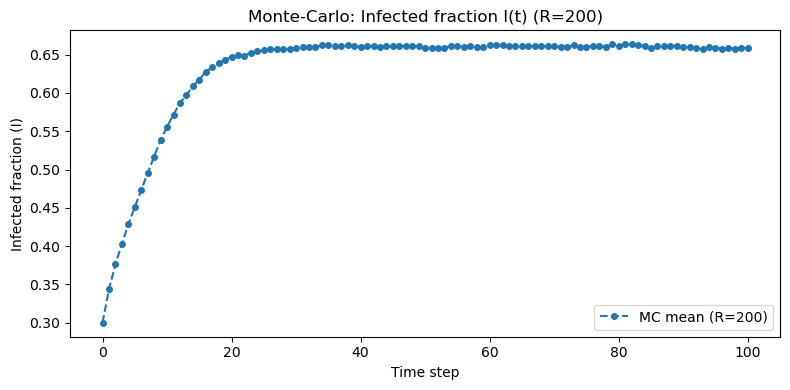

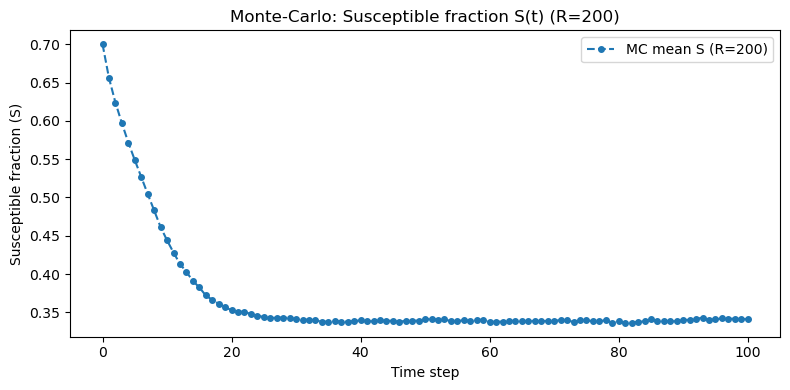

Final infected (MC mean): 0.6588
Done.


In [ ]:
# 读取数据 
# 读取 rho_runs
rho_df = pd.read_csv("./rho_runs_mc.csv")
rho_runs = rho_df.values  # 转回 NumPy 数组

# 读取 mean_rho_mc
mean_df = pd.read_csv("./mean_rho_mc.csv")
ts = mean_df['time'].values
mean_rho_mc = mean_df['mean_rho_mc'].values

# Susceptible fractions
mean_S_mc = 1.0 - mean_rho_mc

# 绘图：I(t) 均值
plt.figure(figsize=(8,4))
plt.plot(ts, mean_rho_mc, linestyle='--', marker='o', markersize=4, label=f'MC mean (R={R})')
plt.xlabel("Time step")
plt.ylabel("Infected fraction (I)")
plt.title(f"Monte-Carlo: Infected fraction I(t) (R={R})")
plt.legend()
plt.tight_layout()
plt.show()

# 绘图：S(t)
plt.figure(figsize=(8,4))
plt.plot(ts, mean_S_mc, linestyle='--', marker='o', markersize=4, label=f'MC mean S (R={R})')
plt.xlabel("Time step")
plt.ylabel("Susceptible fraction (S)")
plt.title(f"Monte-Carlo: Susceptible fraction S(t) (R={R})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final infected (MC mean): {mean_rho_mc[-1]:.4f}")
print("Done.")